# H2: K-модальная структура эхо-камер

## Гипотеза

Если пользовательская популяция **гетерогенна** — состоит из K отдельных сегментов — 
то feedback loop порождает **K независимых эхо-камер**: 
каждый кластер коллапсирует к собственному аттрактору, а расстояния между кластерами 
при этом сохраняются.

Формально: при замкнутом цикле рекомендаций ковариации внутри кластеров сжимаются, 
тогда как центроиды остаются разделёнными:

$$\hat{\Sigma}_{k,t}^u \to 0 \quad \forall k, \qquad
\|\mu_k - \mu_j\|_2 \approx \text{const}, \quad k \neq j$$

## Связь с другими гипотезами

| Гипотеза | Что проверяет |
|----------|--------------|
| **H1** | Глобальный дрейф всего распределения (KL) |
| **H2** | Локальный коллапс внутри K кластеров при сохранении межкластерной структуры |
| **H3** | Сравнение силы эффекта: closed_loop vs. no_influence |

H2 детализирует H1: дрейф идёт **раздельно в каждом кластере**, 
поэтому система деградирует не в одну точку, а в K точек — по числу сегментов аудитории.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from pathlib import Path
from sklearn.decomposition import PCA

from sim.environment import SimulationEnvironment, ExperimentDataset
from sim.user_generator import GMMUserGenerator
from sim.click_model import ClickModel
from models.rec_models import RecModel
from models.serving import ServingPolicy

matplotlib.rcParams['figure.dpi'] = 120
FIGURES_DIR = Path('../paper/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EMB_DIM = 4
N_ITEMS = 60
K = 5
T = 80
PERIOD = 5

np.random.seed(42)
items_emb = np.random.randn(N_ITEMS, EMB_DIM)
print('Imports OK')

Imports OK


## Параметры эксперимента

| Параметр | Значение | Смысл |
|----------|---------|-------|
| `EMB_DIM` | 4 | Размерность векторных представлений (пользователи и объекты) |
| `N_ITEMS` | 60 | Число объектов в каталоге |
| `K` | 5 | Размер рекомендательного списка (top-K) |
| `T` | 80 | Длина симуляции в шагах |
| `PERIOD` | 5 | Как часто переобучается рекомендательная модель |

**Варьируемые параметры:**

| Параметр | Значения | Что изучаем |
|----------|---------|------------|
| `K_values` | 1, 2, 4 | Число кластеров GMM (ключевой параметр H2) |
| `inter_dist` | 2.0, 4.0, 6.0 | Расстояние между центрами кластеров |
| `overlap` | 0.2, 0.5 | Степень перекрытия распределений соседних кластеров |

> **Допущение о симметрии:** центры кластеров равномерно расположены по окружности 
> в первых двух измерениях пространства эмбеддингов. 
> Это упрощает интерпретацию, сохраняя общность.

In [2]:
def make_gmm_config(K_comp, inter_dist, overlap):
 """Создаёт конфигурацию GMM с K компонентами."""
 np.random.seed(0)
 means = []
 angle_step = 2 * np.pi / K_comp
 for k in range(K_comp):
 mu = np.zeros(EMB_DIM)
 mu[0] = inter_dist * np.cos(k * angle_step)
 mu[1] = inter_dist * np.sin(k * angle_step)
 means.append(mu)

 sigma_scale = overlap * inter_dist / 2
 covs = [sigma_scale * np.eye(EMB_DIM) for _ in range(K_comp)]
 weights = np.ones(K_comp) / K_comp
 return means, covs, weights

def run_simulation(K_comp, inter_dist=3.0, overlap=0.3, n_users=120, seed=42):
 np.random.seed(seed)
 torch.manual_seed(seed)

 means, covs, weights = make_gmm_config(K_comp, inter_dist, overlap)
 gen = GMMUserGenerator(means, covs, weights, replacement_rate=0.04)
 user_emb, cluster_labels = gen.initialize(n_users)

 true_pref = (user_emb @ items_emb.T)
 true_pref = (true_pref - true_pref.min()) / (true_pref.max() - true_pref.min() + 1e-9)
 matrix = np.full((n_users, N_ITEMS), np.nan)

 dataset = ExperimentDataset(user_emb.copy(), items_emb.copy(), matrix)
 model = RecModel(EMB_DIM, EMB_DIM, hidden_size=32)
 policy = ServingPolicy(mode='top_k')
 click = ClickModel(adherence=0.7, usage_rate=0.8)

 env = SimulationEnvironment(
 dataset=dataset, rec_model=model,
 user_generator=gen, click_model=click,
 serving_policy=policy, mode='closed_loop',
 true_preference_matrix=true_pref,
 retrain_period=PERIOD,
 seen_filter=True, user_drift_beta=0.005, drift_alpha=0.0, K=K)

 # Сохраняем снапшоты эмбеддингов
 snapshots = {}
 snap_steps = [0, T//4, T//2, T-1]

 for t in range(T):
 env.step(t)
 if t in snap_steps:
 snapshots[t] = (
 env.dataset.users_embeddings.copy(),
 env.user_gen.cluster_labels.copy()
 )

 return env.metrics.get_dataframe(), snapshots, K_comp

print('Functions defined')

Functions defined


## Компоненты симуляции

### 1. Генератор пользователей: GMM (Gaussian Mixture Model)

Начальное распределение пользователей:
$$P_0 = \sum_{k=1}^K w_k \, \mathcal{N}(\mu_k,\, \sigma_k^2 I), \qquad w_k = 1/K$$

**Центры** μ_k размещены по окружности радиуса `inter_dist`; 
**дисперсия** σ_k пропорциональна `inter_dist × overlap`. 
Смена аудитории: каждый шаг доля пользователей уходит, новые сэмплируются из текущего GMM.

### 2. Рекомендательная модель: бинарный нейросетевой классификатор

`RecModel` — двухбашенная архитектура (user-tower + item-tower): 
принимает эмбеддинги пользователя $u$ и объекта $v$, предсказывает $P(\text{клик}) \in [0,1]$. 
Обучается каждые `PERIOD` шагов на накопленных взаимодействиях через `BCELoss`.

### 3. Механизм β-дрейфа предпочтений

После каждого взаимодействия эмбеддинг пользователя сдвигается:
$$u_i^{t+1} = (1 - \beta)\, u_i^t + \beta\, v_{j(i,t)}$$
где $v_{j(i,t)}$ — вектор потреблённого объекта, $\beta$ = `user_drift_beta`. 
В `closed_loop`: рекомендатель продвигает популярные объекты -> пользователи кластера k 
дрейфуют к **одному** объекту -> tr(Σ̂_k) -> 0.

### 4. Ключевые метрики

| Метрика | Формула / смысл |
|--------|----------------|
| `intra_cluster_variance` | $\frac{1}{K}\sum_k \operatorname{tr}(\hat{\Sigma}_k^u)$ — суммарный разброс внутри кластеров |
| `inter_cluster_distance` | Среднее $\|\mu_k - \mu_j\|$ между парами центроидов |
| `silhouette_score` | Насколько чётко разделены кластеры (подробнее ниже) |

In [3]:
# ── Сетка экспериментов ───────────────────────────────────────────────
K_values = [1, 2, 4]
inter_dists = [2.0, 4.0, 6.0]
overlaps = [0.2, 0.5]

# Основной прогон: K × inter_dist при overlap=0.3
grid_results = {}
for K_comp in K_values:
 for d in inter_dists:
 key = (K_comp, d)
 df, snaps, _ = run_simulation(K_comp, inter_dist=d, overlap=0.3)
 grid_results[key] = df
 print(f'K={K_comp}, d={d:.1f} ')

K=1, d=2.0 


K=1, d=4.0 


K=1, d=6.0 


K=2, d=2.0 


K=2, d=4.0 


K=2, d=6.0 


K=4, d=2.0 


K=4, d=4.0 


K=4, d=6.0 


## Интерпретация сеточного эксперимента

Для каждой пары (K, `inter_dist`) прогоняем полную симуляцию и измеряем три вещи:

1. **Внутрикластерную дисперсию** tr(Σ̂_k) при t=T — насколько «схлопнулся» каждый кластер.
2. **Силуэтный коэффициент** — сохраняются ли кластеры разделёнными в конце.
3. **PCA-снапшоты** — визуальное подтверждение независимого коллапса.

**Ожидаемые паттерны:**

| Конфигурация | Внутри-кластерная дисперсия | Силуэт | Интерпретация |
|-------------|--------------------------|--------|--------------|
| K=1 | -> 0 | N/A | Один глобальный коллапс |
| K>1, большой `inter_dist` | -> 0 для каждого k | Высокий | K независимых эхо-камер H2 |
| K>1, малый `inter_dist` | -> 0, кластеры сливаются | Низкий | Слияние в одну эхо-камеру |

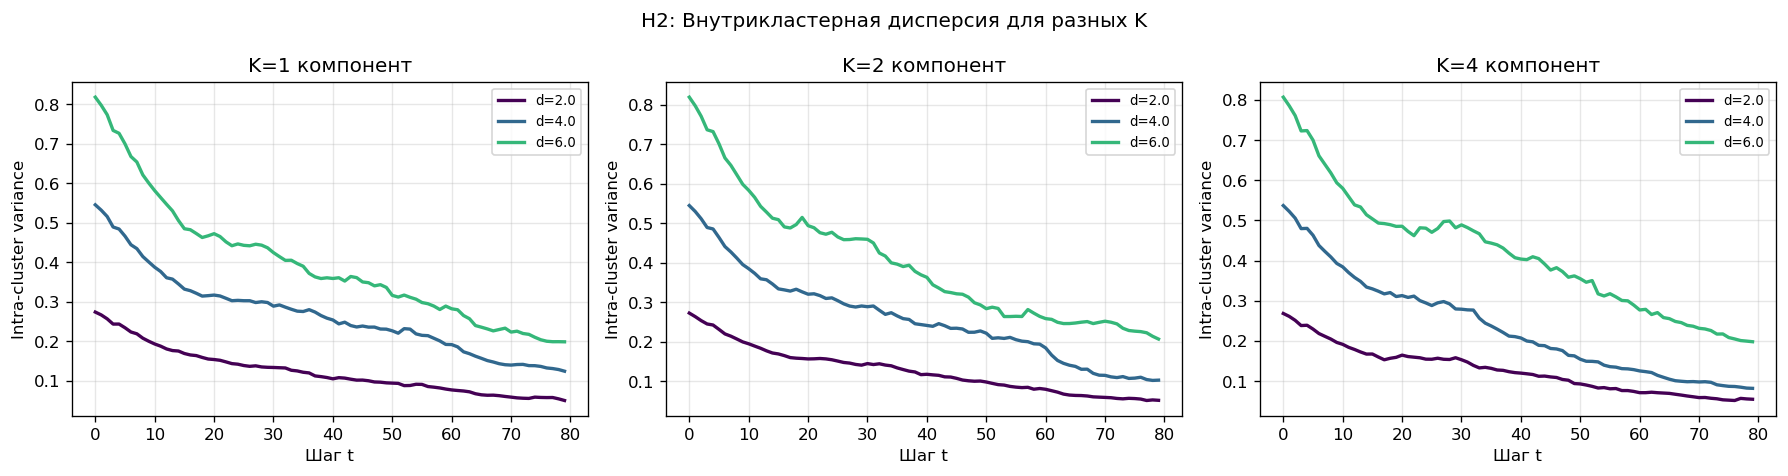

In [4]:
# ── Рисунок 1: intra_cluster_variance по K ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cmap = plt.cm.viridis

for ax_idx, K_comp in enumerate(K_values):
 ax = axes[ax_idx]
 for ci, d in enumerate(inter_dists):
 df = grid_results[(K_comp, d)]
 color = cmap(ci / len(inter_dists))
 ax.plot(df['t'], df['intra_cluster_variance'],
 color=color, lw=2, label=f'd={d:.1f}')
 ax.set_title(f'K={K_comp} компонент')
 ax.set_xlabel('Шаг t')
 ax.set_ylabel('Intra-cluster variance')
 ax.legend(fontsize=8)
 ax.grid(alpha=0.3)

plt.suptitle('H2: Внутрикластерная дисперсия для разных K')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'H2_intra_cluster_variance.pdf', bbox_inches='tight')
plt.show()

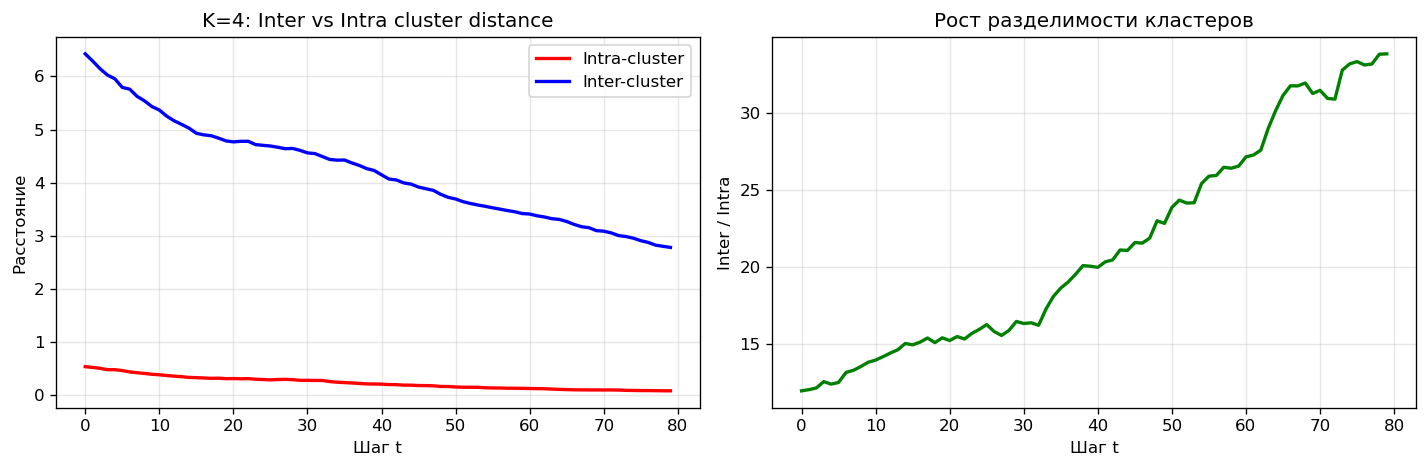

In [5]:
# ── Рисунок 2: inter vs intra distance ───────────────────────────────
df_K4, snaps_K4, _ = run_simulation(K_comp=4, inter_dist=4.0, overlap=0.3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_K4['t'], df_K4['intra_cluster_variance'], 'r-', lw=2, label='Intra-cluster')
axes[0].plot(df_K4['t'], df_K4['inter_cluster_distance'], 'b-', lw=2, label='Inter-cluster')
axes[0].set_xlabel('Шаг t')
axes[0].set_ylabel('Расстояние')
axes[0].set_title('K=4: Inter vs Intra cluster distance')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Отношение inter/intra
ratio = df_K4['inter_cluster_distance'] / (df_K4['intra_cluster_variance'] + 1e-9)
axes[1].plot(df_K4['t'], ratio, 'g-', lw=2)
axes[1].set_xlabel('Шаг t')
axes[1].set_ylabel('Inter / Intra')
axes[1].set_title('Рост разделимости кластеров')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'H2_inter_intra_ratio.pdf', bbox_inches='tight')
plt.show()

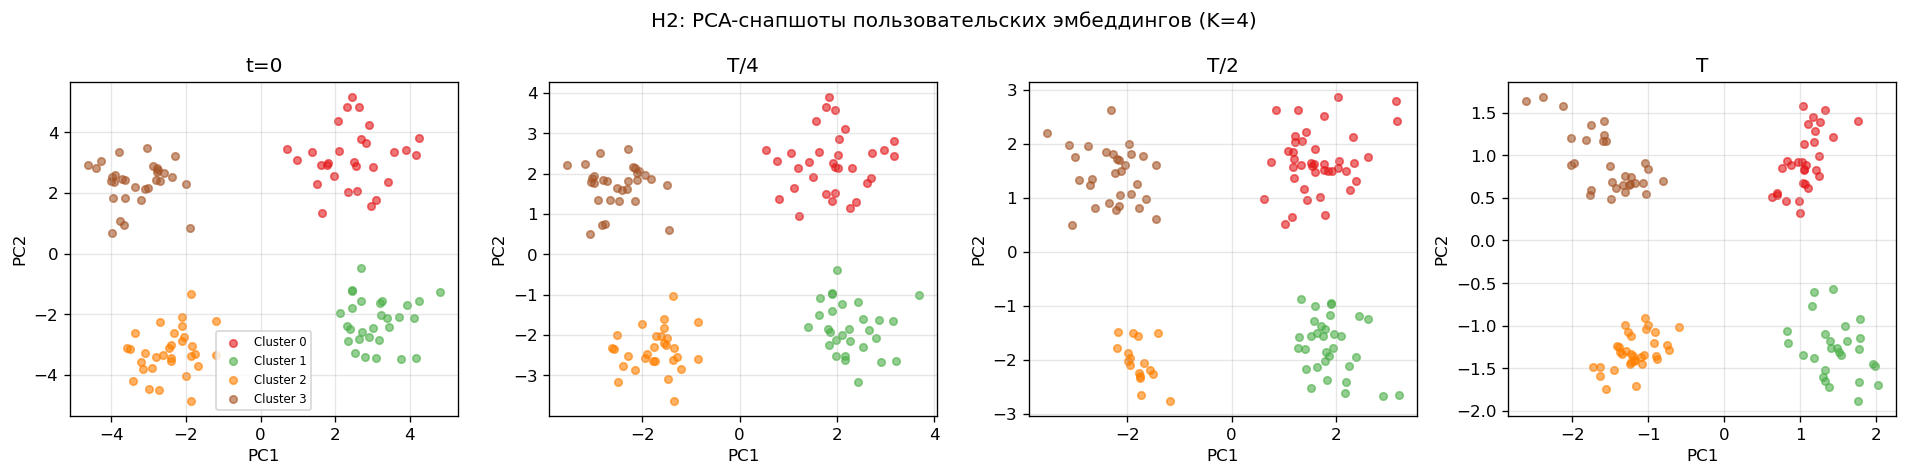

In [6]:
# ── Рисунок 3: PCA снапшоты для K=4 ─────────────────────────────────
df_snap, snaps, _ = run_simulation(K_comp=4, inter_dist=4.0, overlap=0.3, seed=42)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
step_labels = ['t=0', 'T/4', 'T/2', 'T']
cmap_pts = plt.cm.Set1

all_embs = np.vstack([snaps[s][0] for s in sorted(snaps.keys())])
pca = PCA(n_components=2)
pca.fit(all_embs)

for ax_idx, (step, label) in enumerate(zip(sorted(snaps.keys()), step_labels)):
 embs, labels = snaps[step]
 proj = pca.transform(embs)
 ax = axes[ax_idx]
 for k in range(4):
 mask = labels == k
 if mask.sum() > 0:
 ax.scatter(proj[mask, 0], proj[mask, 1],
 c=[cmap_pts(k/4)], alpha=0.6, s=20, label=f'Cluster {k}')
 ax.set_title(label)
 ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
 if ax_idx == 0:
 ax.legend(fontsize=7)
 ax.grid(alpha=0.3)

plt.suptitle('H2: PCA-снапшоты пользовательских эмбеддингов (K=4)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'H2_pca_snapshots.pdf', bbox_inches='tight')
plt.show()

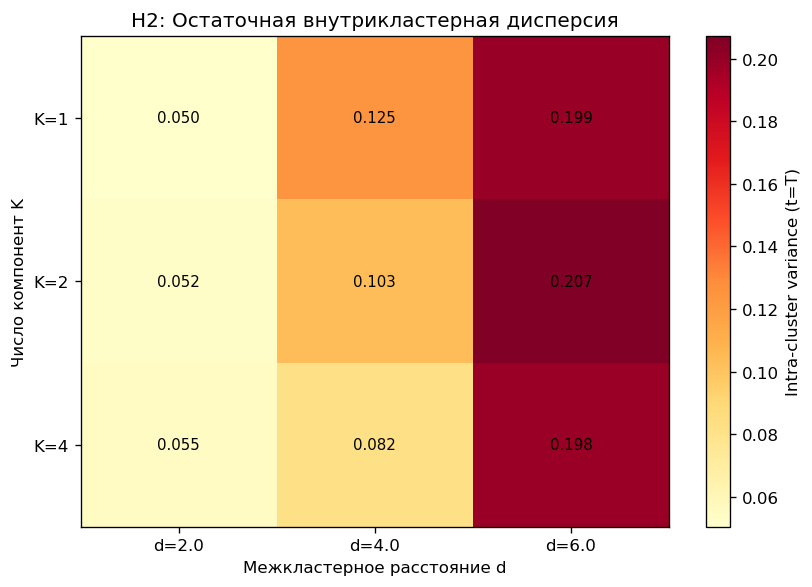

In [7]:
# ── Heatmap: intra_cluster_variance в точке T по (K, d) ──────────────
heat_data = np.zeros((len(K_values), len(inter_dists)))
for i, Kc in enumerate(K_values):
 for j, d in enumerate(inter_dists):
 df = grid_results[(Kc, d)]
 heat_data[i, j] = df['intra_cluster_variance'].iloc[-1]

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(heat_data, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(inter_dists))); ax.set_xticklabels([f'd={d:.1f}' for d in inter_dists])
ax.set_yticks(range(len(K_values))); ax.set_yticklabels([f'K={k}' for k in K_values])
plt.colorbar(im, label='Intra-cluster variance (t=T)')
ax.set_title('H2: Остаточная внутрикластерная дисперсия')
ax.set_xlabel('Межкластерное расстояние d')
ax.set_ylabel('Число компонент K')
for i in range(len(K_values)):
 for j in range(len(inter_dists)):
 ax.text(j, i, f'{heat_data[i,j]:.3f}', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'H2_heatmap_intra_variance.pdf', bbox_inches='tight')
plt.show()

## Силуэтный коэффициент как мера структурированности популяции

**Силуэтный коэффициент** $s(i)$ для пользователя $i$:
$$s(i) = \frac{b(i) - a(i)}{\max\bigl(a(i),\, b(i)\bigr)}, \quad s \in [-1, 1]$$

| Компонент | Определение |
|----------|------------|
| $a(i)$ | Среднее расстояние до пользователей **того же** кластера |
| $b(i)$ | Среднее расстояние до пользователей **ближайшего чужого** кластера |
| $s = 1$ | Идеально разделённые кластеры |
| $s = 0$ | Пользователь на границе кластеров |
| $s < 0$ | Пользователь ошибочно отнесён к кластеру |

**Для проверки H2**: если силуэт **не падает** со временем при K>1, это означает, 
что K независимых эхо-камер сохраняют свою структуру и не сливаются.

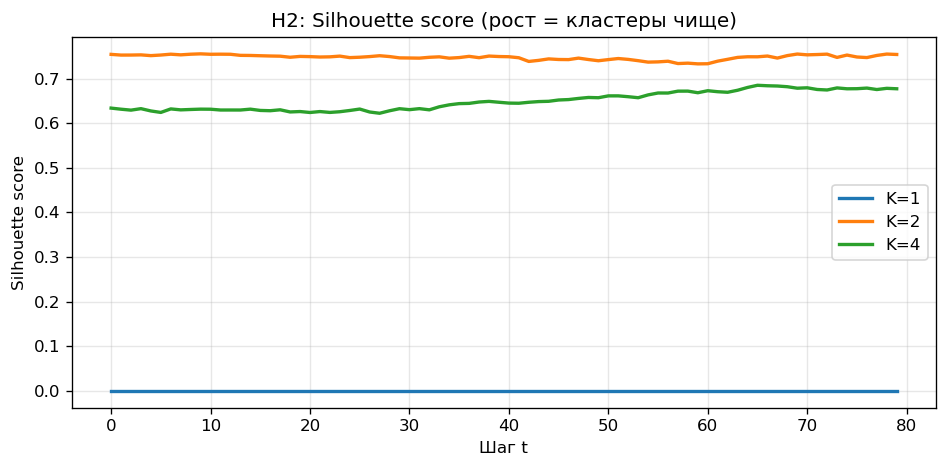


=== H2 summary ===
K=1: intra_var 0.546 -> 0.125, silhouette 0.000 -> 0.000
K=2: intra_var 0.545 -> 0.103, silhouette 0.754 -> 0.754
K=4: intra_var 0.537 -> 0.082, silhouette 0.634 -> 0.677


In [8]:
# ── Silhouette score ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for K_comp in K_values:
 df = grid_results[(K_comp, 4.0)]
 ax.plot(df['t'], df['silhouette_score'], lw=2, label=f'K={K_comp}')
ax.set_xlabel('Шаг t'); ax.set_ylabel('Silhouette score')
ax.set_title('H2: Silhouette score (рост = кластеры чище)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'H2_silhouette.pdf', bbox_inches='tight')
plt.show()

print('\n=== H2 summary ===')
for K_comp in K_values:
 df = grid_results[(K_comp, 4.0)]
 print(f'K={K_comp}: intra_var {df["intra_cluster_variance"].iloc[0]:.3f} -> '
 f'{df["intra_cluster_variance"].iloc[-1]:.3f}, '
 f'silhouette {df["silhouette_score"].iloc[0]:.3f} -> '
 f'{df["silhouette_score"].iloc[-1]:.3f}')